# Parte 1 - DBSCAN Clustering Básico

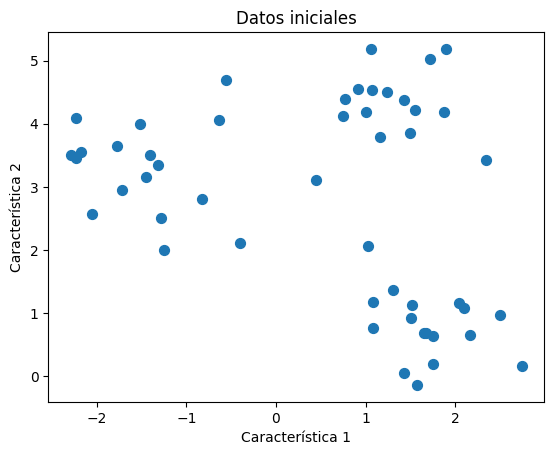

In [ ]:
# Importamos las bibliotecas necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs

# Generación de datos simples para el clustering
np.random.seed(42)
X, y = make_blobs(n_samples=50, centers=3, cluster_std=0.60, random_state=0)

# Visualización inicial de los datos
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title('Datos iniciales')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.show()




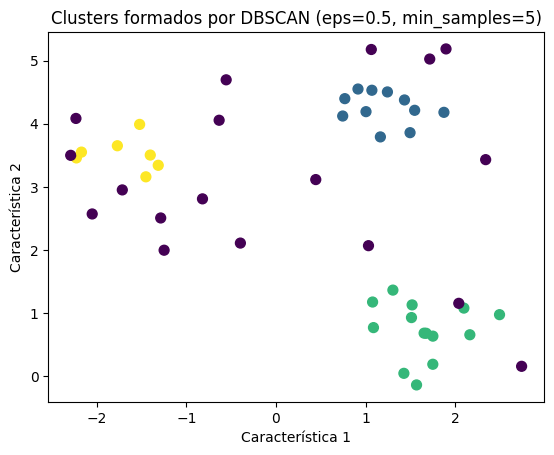

In [ ]:
# Aplicación de DBSCAN con parámetros básicos
dbscan = DBSCAN(eps=0.5, min_samples=5)  # Valores iniciales de epsilon y min_samples
y_dbscan = dbscan.fit_predict(X)

# Visualización de los clusters formados
plt.scatter(X[:, 0], X[:, 1], c=y_dbscan, cmap='viridis', s=50)  # Coloreamos los puntos según su cluster
plt.title('Clusters formados por DBSCAN (eps=0.5, min_samples=5)')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.show()

# Explicación:
# DBSCAN es un algoritmo basado en densidad que agrupa puntos que están densamente conectados.
# Los puntos ruidosos (outliers) se asignan como -1.

In [ ]:
import pandas as pd
pd.DataFrame({"X":X[:,0], "Y":X[:,1], "Etiqueta":y_dbscan})

,X,Y,Etiqueta
0,1.546323,4.212973,0
1,1.674674,0.680019,1
2,1.242588,4.503992,0
3,1.164111,3.791330,0
4,-1.768810,3.651349,2
5,0.443599,3.115309,-1
6,-1.520604,3.989405,2
7,-0.397014,2.109227,-1
8,1.651791,0.681932,1
9,-1.285499,2.506996,-1


# Parte 2 - Ajuste de Parámetros en DBSCAN

En la Parte 2, ajustaremos los parámetros de DBSCAN, como eps y min_samples, para ver cómo afectan al agrupamiento. Vamos a iterar sobre diferentes valores y mostrar los resultados.

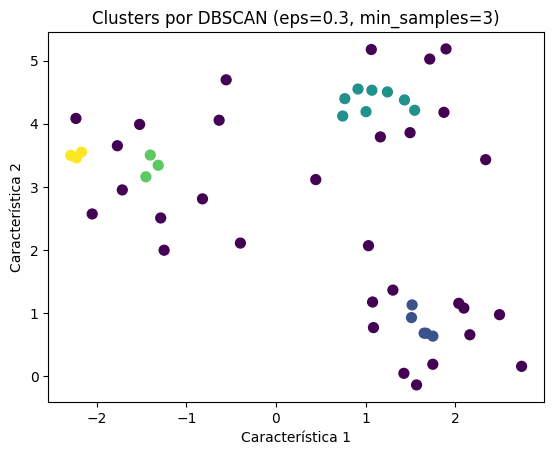

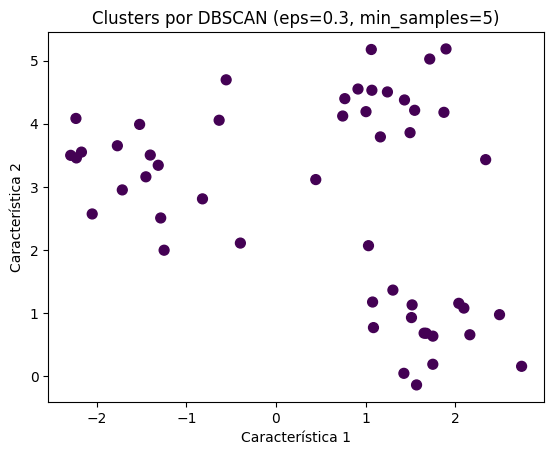

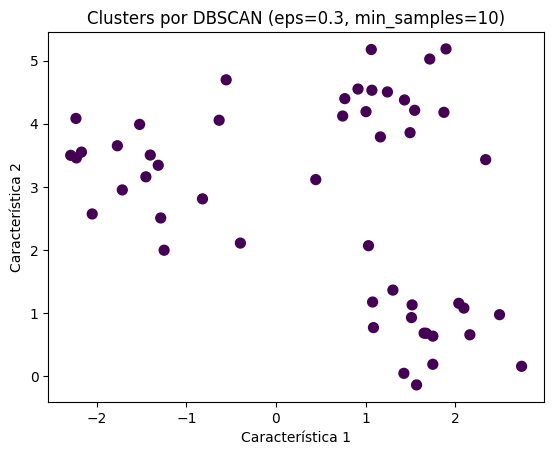

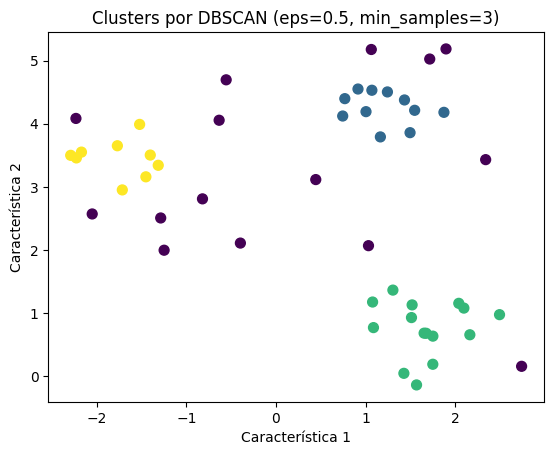

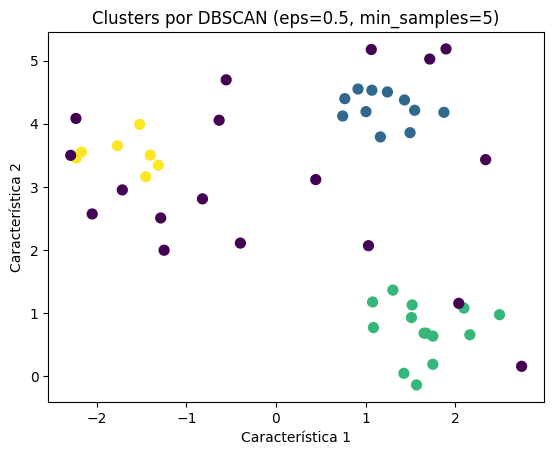

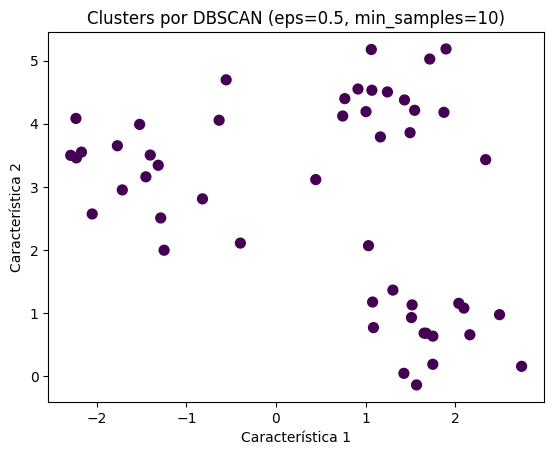

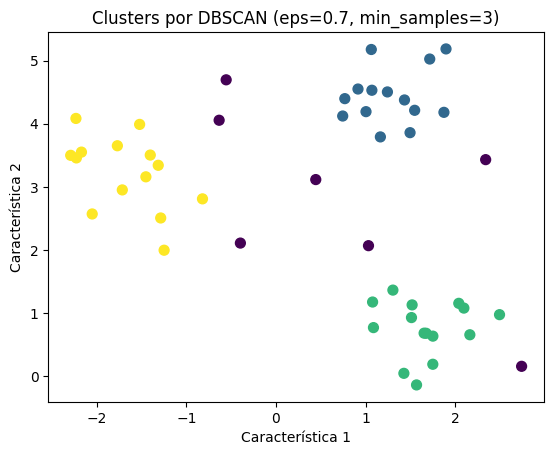

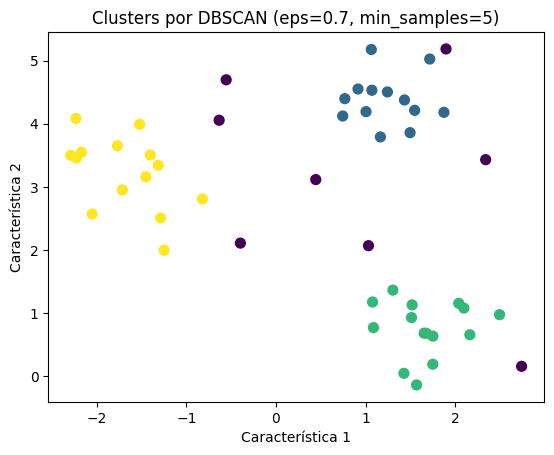

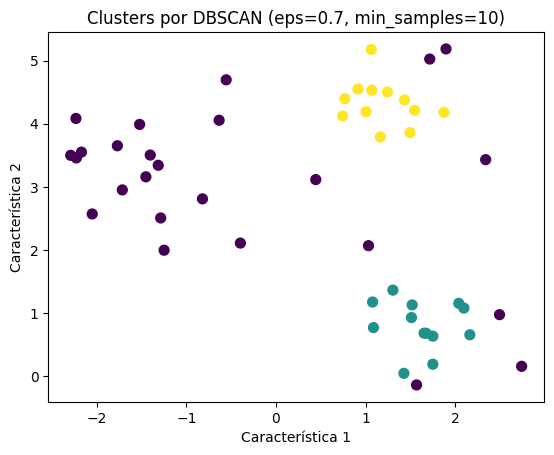

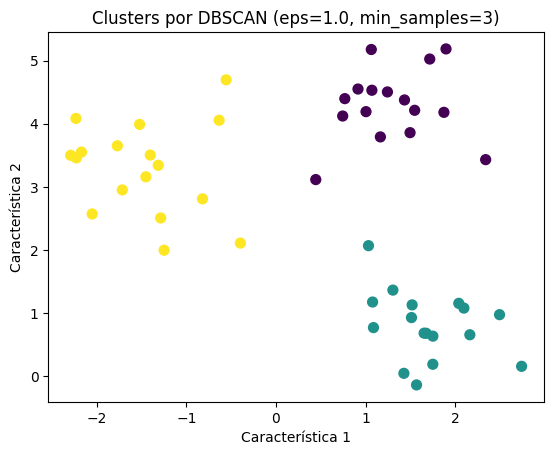

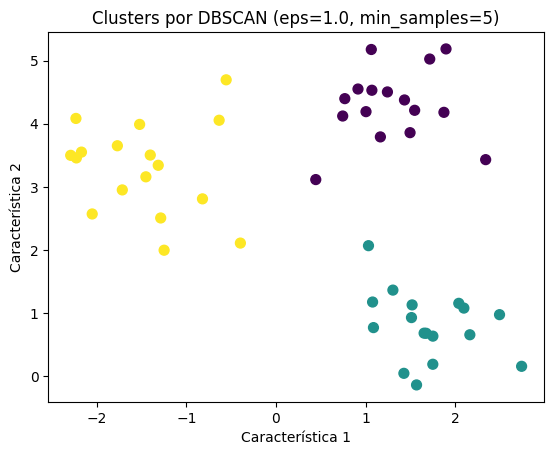

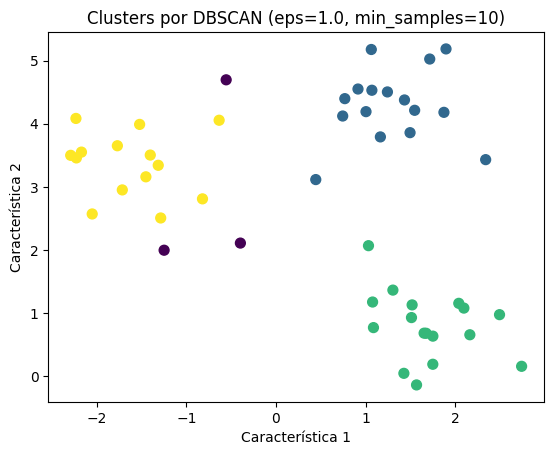

In [ ]:
# Iteramos sobre diferentes valores de eps y min_samples
eps_values = [0.3, 0.5, 0.7, 1.0]
min_samples_values = [3, 5, 10]

for eps in eps_values:
    for min_samples in min_samples_values:
        # Aplicación de DBSCAN con los diferentes valores de eps y min_samples
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        y_dbscan = dbscan.fit_predict(X)

        # Visualización de los clusters formados
        plt.scatter(X[:, 0], X[:, 1], c=y_dbscan, cmap='viridis', s=50)
        plt.title(f'Clusters por DBSCAN (eps={eps}, min_samples={min_samples})')
        plt.xlabel('Característica 1')
        plt.ylabel('Característica 2')
        plt.show()

# Explicación:
Hemos variado los parámetros de DBSCAN:
 - eps: distancia máxima entre dos puntos para considerarse vecinos.
 - min_samples: número mínimo de puntos para formar un núcleo denso.

Observamos cómo los clusters cambian según estos valores.

# Parte 3: Comparativa entre Clustering Jerárquico, K-Means y DBSCAN

En la Parte 3, vamos a realizar una comparativa entre los algoritmos Jerárquico, K-Means y DBSCAN. Para ello, aplicaremos los tres algoritmos al mismo conjunto de datos y visualizaremos los resultados uno al lado del otro para observar las diferencias en cómo cada uno agrupa los puntos.

In [ ]:
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [ ]:
# Clustering Jerárquico (enlace completo)
Z = linkage(X, method='complete')
clusters_hierarchical = fcluster(Z, t=3, criterion='maxclust')

# K-Means con 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X)

# DBSCAN con parámetros ajustados
dbscan = DBSCAN(eps=1, min_samples=5)
y_dbscan = dbscan.fit_predict(X)


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [ ]:
import pandas as pd
pd.DataFrame({"X":X[:,0], "Y":X[:,1], "Etiqueta Jerárquico":clusters_hierarchical, "Etiqueta K-Means":y_kmeans, "Etiqueta DBSCAN":y_dbscan})

,X,Y,Etiqueta Jerárquico,Etiqueta K-Means,Etiqueta DBSCAN
0,1.546323,4.212973,3,2,0
1,1.674674,0.680019,1,1,1
2,1.242588,4.503992,3,2,0
3,1.164111,3.791330,3,2,0
4,-1.768810,3.651349,2,0,2
5,0.443599,3.115309,3,2,0
6,-1.520604,3.989405,2,0,2
7,-0.397014,2.109227,2,0,2
8,1.651791,0.681932,1,1,1
9,-1.285499,2.506996,2,0,2


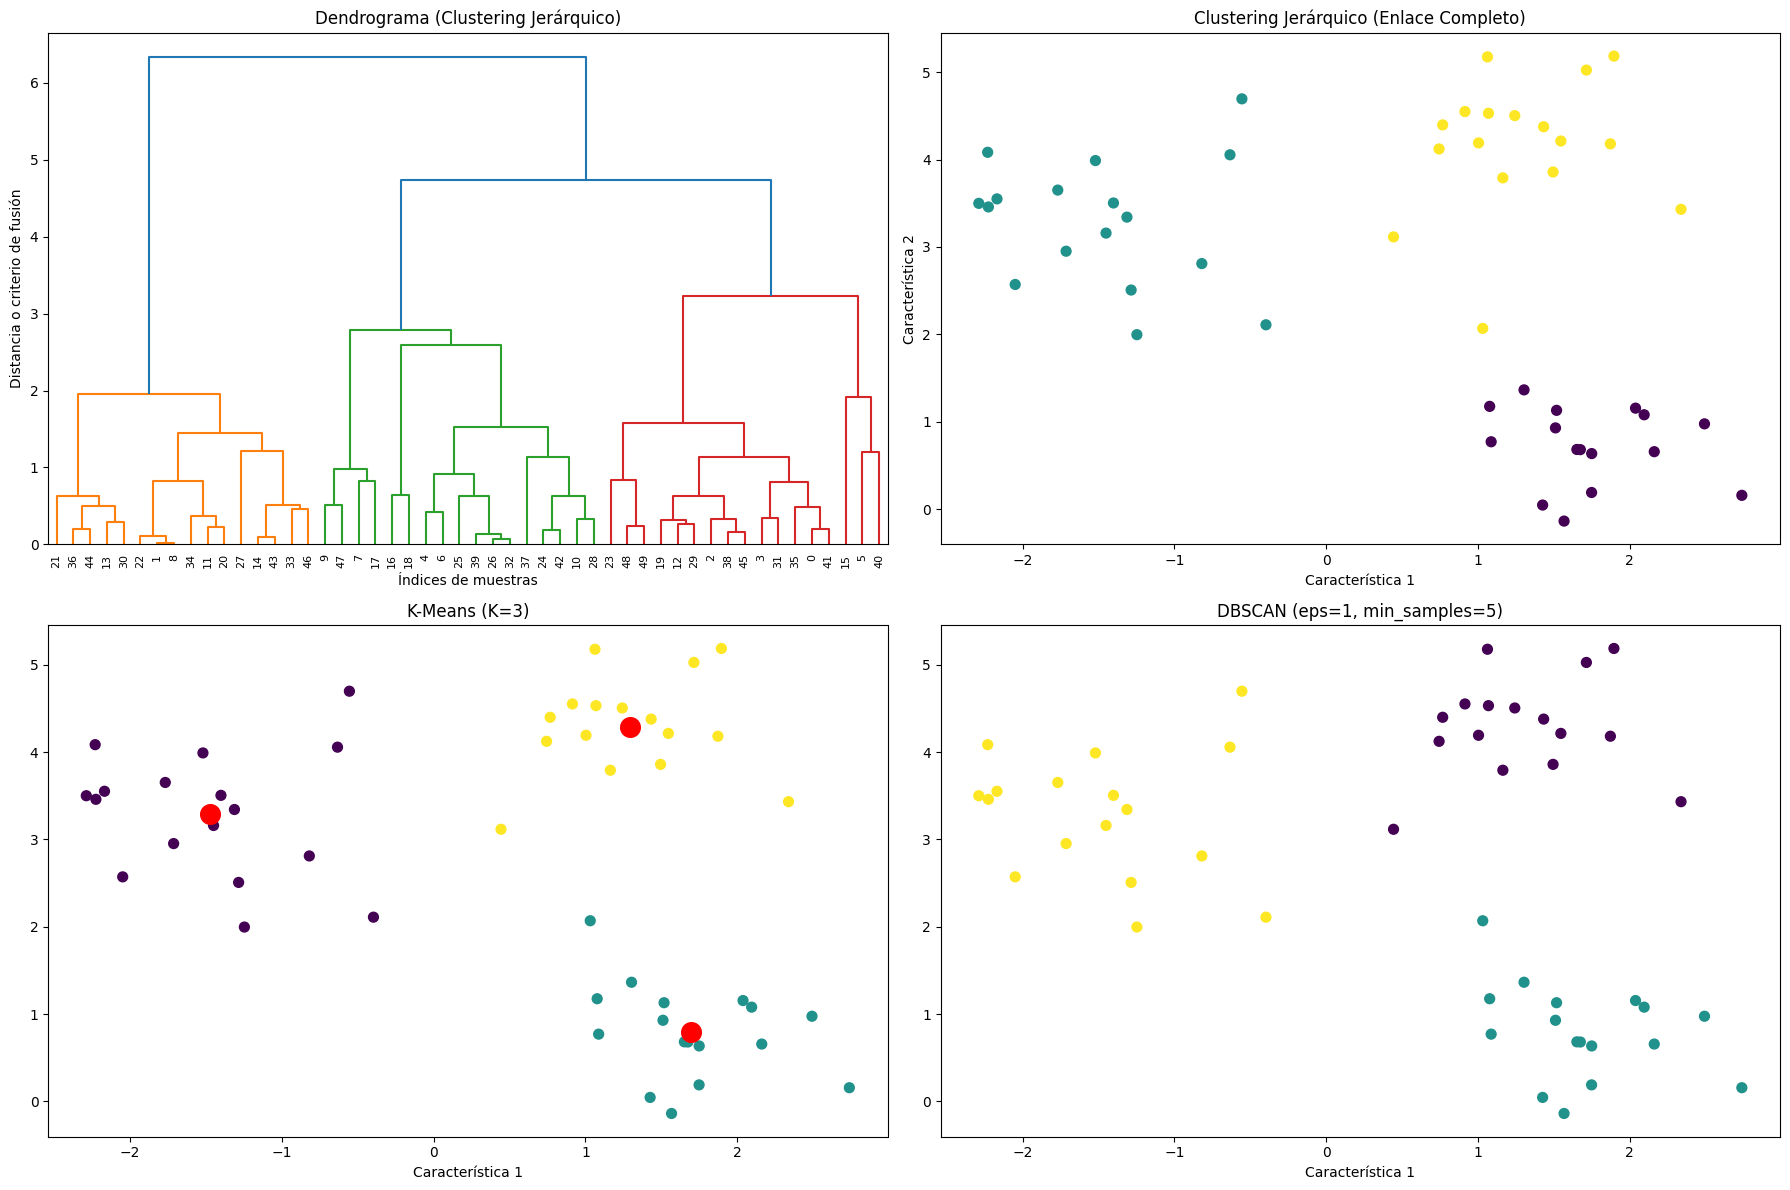

In [ ]:
# Visualización comparativa de los 3 algoritmos

plt.figure(figsize=(18, 12))

# Subplot 1: Dendrograma del Clustering Jerárquico
plt.subplot(2, 2, 1)
dendrogram(Z)
plt.title('Dendrograma (Clustering Jerárquico)')
plt.xlabel('Índices de muestras')
plt.ylabel('Distancia o criterio de fusión')

# Subplot 2: Clustering Jerárquico
plt.subplot(2, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=clusters_hierarchical, cmap='viridis', s=50)
plt.title('Clustering Jerárquico (Enlace Completo)')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')

# Subplot 3: K-Means
plt.subplot(2, 2, 3)
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', label='Centroides')
plt.title('K-Means (K=3)')
plt.xlabel('Característica 1')

# Subplot 4: DBSCAN
plt.subplot(2, 2, 4)
plt.scatter(X[:, 0], X[:, 1], c=y_dbscan, cmap='viridis', s=50)
plt.title('DBSCAN (eps=1, min_samples=5)')
plt.xlabel('Característica 1')

plt.tight_layout()
plt.show()

# Explicación:
 - Subplot 1: El dendrograma muestra cómo se agrupan los puntos en el clustering jerárquico.
 - Subplot 2: Clustering Jerárquico con los 3 clusters formados.
 - Subplot 3: K-Means con los 3 clusters y los centroides en rojo.
 - Subplot 4: DBSCAN con clusters y posibles outliers (-1).